# Explainability and Calibration

The model comparison shows the best learned model, the logistic regression, adds a real but modest edge over a matched naive baseline on the forward-disjoint target (`FwdVolRegime`, whether the next 10 trading days are a high-volatility regime). XGBoost's own edge (+0.016, p=0.23) does not clear the significance bar. This notebook opens the forecast up with SHAP on XGBoost, chosen because tree models have exact, fast TreeSHAP attributions, reads the logistic regression champion through its own standardized coefficients, then checks whether the predicted probabilities are trustworthy.

Models are trained on data through 2022 and evaluated on the 2023 onward holdout, so both SHAP and the calibration curves are computed on rows the models never saw. The isotonic calibrator is the one exception. To stay temporally valid it is fit on a purged 2022 slice that its underlying model, trained through 2021, never saw, rather than on shuffled folds inside the training window.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator
from sklearn.metrics import brier_score_loss

from src.config import load_config
from src.pipeline import load_data, prepare_features_and_labels
from src.modeling import train_xgboost, train_lightgbm, train_logistic_regression, add_har_features
from src.split import generate_expanding_window_splits, get_fold_indices
from src.targets import add_regime_columns

sns.set_style("whitegrid")

CRIMSON, STEEL, AMBER = "#DC143C", "#4682B4", "#c58f00"
FIG = ROOT / "reports" / "figures"

cfg = load_config()
features = cfg["data"]["features"]
target = cfg["data"]["target"]

## Train through 2022, explain 2023 onward

In [2]:
df = load_data(str(ROOT / cfg["data"]["input_path"]))
df = add_regime_columns(add_har_features(df), forward_window=cfg["evaluation"]["forward_window"])
train = df[(df["Date"] <= "2022-12-31") & (df["label_end_forward"] < pd.Timestamp("2023-01-01"))]
test = df[df["Date"] > "2022-12-31"]

X_train, y_train, _ = prepare_features_and_labels(train, features, target)
X_test, y_test, _ = prepare_features_and_labels(test, features, target)

model = train_xgboost(X_train, y_train, **cfg["models"].get("xgboost", {}))
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

print(f"Trained on {len(X_train):,} rows, explaining {len(X_test):,} held-out rows")

Trained on 26,152 rows, explaining 10,570 held-out rows


## Global importance

The bar chart ranks features by mean absolute SHAP value, and the beeswarm shows the direction of each effect.

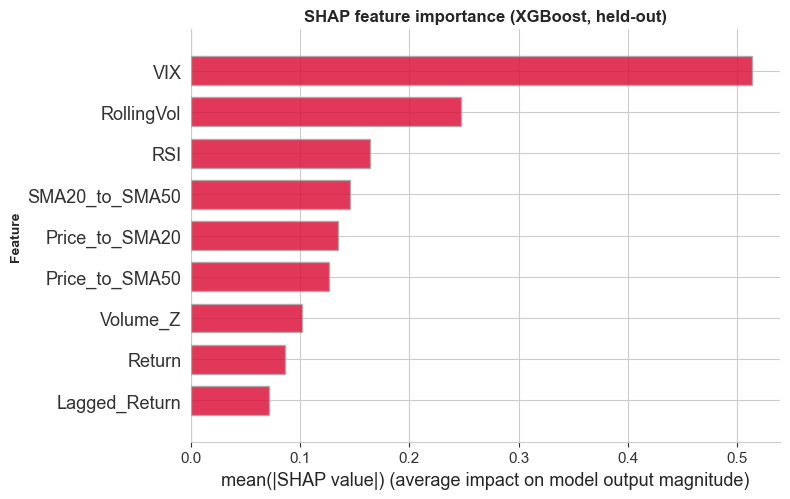

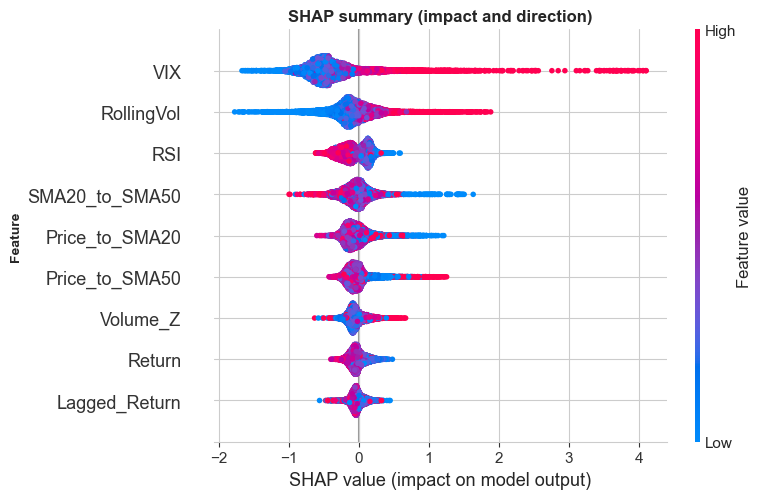

In [3]:
shap.summary_plot(shap_values, X_test, plot_type="bar", color=CRIMSON, show=False)
for patch in plt.gca().patches:
    patch.set_edgecolor("darkgrey")
    patch.set_alpha(0.85)
plt.title("SHAP feature importance (XGBoost, held-out)", fontweight="bold")
plt.ylabel("Feature", fontweight="bold")
plt.tight_layout()
plt.savefig(FIG / "shap_importance.png", dpi=130, bbox_inches="tight")
plt.show()

shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP summary (impact and direction)", fontweight="bold")
plt.ylabel("Feature", fontweight="bold")
plt.tight_layout()
plt.savefig(FIG / "shap_beeswarm.png", dpi=130, bbox_inches="tight")
plt.show()

## Attribution by Volatility Regime

The thirds below are cut from absolute `RollingVol` pooled across all tickers rather than per ticker, so the Calm bucket leans toward perennially quiet names like WMT while the Turbulent bucket leans toward high-volatility names like TSLA and NVDA. Any shift across the bars therefore mixes market state with ticker composition.

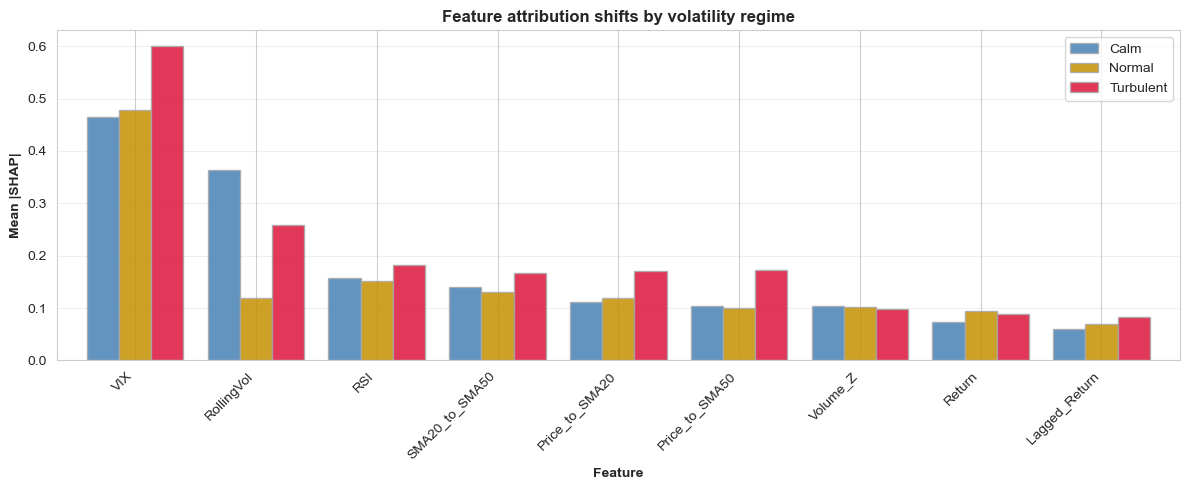

Top feature by regime (mean |SHAP|, share of total attribution):
  Calm       VIX (mean |SHAP| 0.464, 29% of attribution)
  Normal     VIX (mean |SHAP| 0.478, 35% of attribution)
  Turbulent  VIX (mean |SHAP| 0.600, 33% of attribution)


In [4]:
vol = X_test["RollingVol"].to_numpy()
lo, hi = np.quantile(vol, [1/3, 2/3])
regime = np.where(vol <= lo, "Calm", np.where(vol <= hi, "Normal", "Turbulent"))

abs_shap = np.abs(shap_values)
imp = pd.DataFrame(
    {r: abs_shap[regime == r].mean(axis=0) for r in ["Calm", "Normal", "Turbulent"]},
    index=features,
)
order = imp.mean(axis=1).sort_values(ascending=False).index
imp = imp.loc[order]

ax = imp.plot(kind="bar", figsize=(12, 5), color=[STEEL, AMBER, CRIMSON], width=0.8,
              alpha=0.85, edgecolor="darkgrey")
ax.set_ylabel("Mean |SHAP|", fontweight="bold")
ax.set_xlabel("Feature", fontweight="bold")
ax.set_title("Feature attribution shifts by volatility regime", fontweight="bold")
ax.grid(True, alpha=0.3, axis="y")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIG / "shap_by_regime.png", dpi=130, bbox_inches="tight")
plt.show()

print("Top feature by regime (mean |SHAP|, share of total attribution):")
for r in ["Calm", "Normal", "Turbulent"]:
    share = imp[r].max() / imp[r].sum()
    print(f"  {r:10s} {imp[r].idxmax()} (mean |SHAP| {imp[r].max():.3f}, {share:.0%} of attribution)")

## Regime Attribution Results

Splitting the held-out rows into calm, normal, and turbulent thirds by current volatility, VIX is the single largest contributor in every regime, roughly a third of the total attribution (29% calm, 35% normal, 33% turbulent). Current realized volatility is a clear second in the calm and turbulent thirds, though it falls to fifth in the normal third behind the technical ratios. In none of the thirds does a backward-looking technical indicator dominate, and the forecast stays anchored by the market's implied-volatility gauge. Attribution was not computed for the next-day target, but notebook 02 shows a one-line rule built from today's volatility beating every learned model there, which hints that the next-day task leans on backward-looking volatility in a way this forward forecast does not.

## Logistic regression coefficients

The saved champion is the logistic regression, so its own weights, not only the XGBoost SHAP above, should say what drives the forecast. The features enter standardized, so the coefficients are comparable in magnitude and their sign gives the direction of effect. The bars are the mean across the walk-forward folds and the whiskers are one standard deviation, so a short whisker means a weight that holds over time.

/Users/tisyasharma/Projects/volatility-regime-forecasting/src/split.py:61: RuntimeWarning: Final fold is partial, 9 of 63 test days
  warnings.warn(


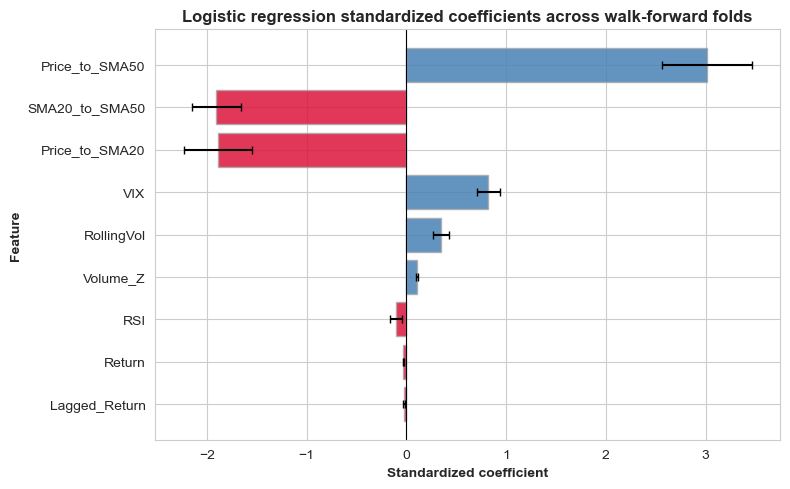

29 walk-forward folds
       feature  through_2022  walkforward_mean  walkforward_std
Price_to_SMA50         2.765             3.009            0.452
SMA20_to_SMA50        -1.754            -1.905            0.248
Price_to_SMA20        -1.710            -1.889            0.342
           VIX         0.856             0.819            0.116
    RollingVol         0.389             0.350            0.079
      Volume_Z         0.108             0.107            0.007
           RSI        -0.152            -0.102            0.063
        Return        -0.035            -0.032            0.006
 Lagged_Return        -0.033            -0.026            0.011


In [5]:
split_cfg = cfg["split"]
splits = generate_expanding_window_splits(
    dates=df["Date"],
    train_start=split_cfg["train_start"],
    initial_train_end=split_cfg["initial_train_end"],
    test_size_days=split_cfg["test_size_days"],
    step_size_days=split_cfg["step_size_days"],
    min_train_size_days=split_cfg["min_train_size_days"],
)
feat_ok = df[features].notna().all(axis=1)
target_ok = df[target].notna()
fold_coefs = []
for tr_s, tr_e, te_s, te_e in splits:
    tr_mask, _ = get_fold_indices(df["Date"], tr_s, tr_e, te_s, te_e, label_end=df["label_end_forward"])
    tr_mask = tr_mask & feat_ok & target_ok
    if tr_mask.sum() < 50:
        continue
    bundle = train_logistic_regression(df.loc[tr_mask, features], df.loc[tr_mask, target])
    fold_coefs.append(bundle["model"].coef_[0])

fold_coefs = np.array(fold_coefs)
coef_mean = fold_coefs.mean(axis=0)
coef_std = fold_coefs.std(axis=0, ddof=1)
coef_2022 = train_logistic_regression(X_train, y_train)["model"].coef_[0]

order = np.argsort(np.abs(coef_mean))
colors = [STEEL if coef_mean[i] > 0 else CRIMSON for i in order]
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(range(len(order)), coef_mean[order], xerr=coef_std[order], color=colors,
        alpha=0.85, edgecolor="darkgrey", capsize=3)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_yticks(range(len(order)))
ax.set_yticklabels([features[i] for i in order])
ax.set_xlabel("Standardized coefficient", fontweight="bold")
ax.set_ylabel("Feature", fontweight="bold")
ax.set_title("Logistic regression standardized coefficients across walk-forward folds", fontweight="bold")
plt.tight_layout()
plt.savefig(FIG / "logreg_coefficients.png", dpi=130, bbox_inches="tight")
plt.show()

coef_table = pd.DataFrame({
    "feature": features,
    "through_2022": np.round(coef_2022, 3),
    "walkforward_mean": np.round(coef_mean, 3),
    "walkforward_std": np.round(coef_std, 3),
})
coef_table = coef_table.reindex(coef_table["walkforward_mean"].abs().sort_values(ascending=False).index)
print(f"{len(fold_coefs)} walk-forward folds")
print(coef_table.to_string(index=False))

## Coefficient results

VIX and current realized volatility carry stable positive weights of about 0.82 and 0.35 in log-odds, so higher implied and realized volatility both raise the forecast probability, the direction the XGBoost SHAP also shows. The three price-to-moving-average ratios take the largest coefficients, but they are near-collinear by construction, since Price_to_SMA20 over Price_to_SMA50 equals one over SMA20_to_SMA50, so their large offsetting weights reflect that redundancy rather than standalone importance. The same collinearity is why the tree-model SHAP, which is robust to it, ranks VIX and volatility on top. The signs hold across every fold except RSI, a small coefficient that flips in a few, so the leading structure is stable.

## Probability Calibration

A model can rank spikes well and still report badly-scaled probabilities. That matters here because the regime label is imbalanced and every learned model is class-weighted to lift recall, balanced weights for logistic regression and LightGBM, a matched `scale_pos_weight` for XGBoost, which is known to inflate predicted probabilities. The reliability diagram below compares each model's predicted probability against the observed regime frequency, with the Brier score as a single summary (lower is better). All three curves are evaluated on the 2023 onward holdout, and both uncalibrated models carry their matched class weights.

calibrator: LGBM fit on 22,638 rows (<=2021), isotonic fit on 3,374 rows (2022)


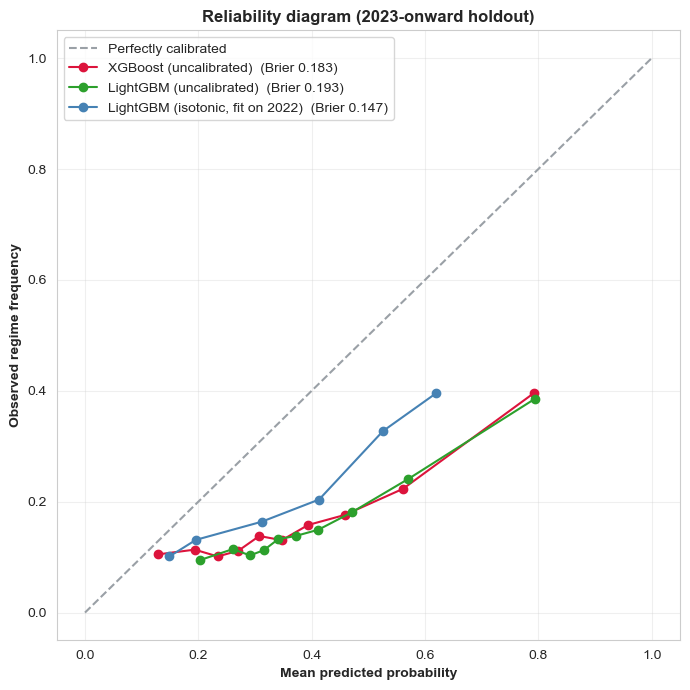

Holdout base rate: 0.165
Mean predicted probability | XGBoost 0.369 | LightGBM 0.403 | LightGBM calibrated 0.274


In [6]:
p_xgb = model.predict_proba(X_test)[:, 1]
lgbm = train_lightgbm(X_train, y_train, **cfg["models"].get("lightgbm", {}))
p_lgbm = lgbm.predict_proba(X_test)[:, 1]

# Temporally valid calibration: fit LightGBM on data through 2021 (purged so no label
# window crosses into 2022), fit the isotonic calibrator on a purged 2022 slice the
# model never saw, and evaluate on the untouched 2023+ holdout. A cv=3 calibrator would
# shuffle time inside the training window, which leaks under serial dependence.
fit_df = df[(df["Date"] <= "2021-12-31") & (df["label_end_forward"] < pd.Timestamp("2022-01-01"))]
cal_df = df[(df["Date"] >= "2022-01-01") & (df["Date"] <= "2022-12-31")
            & (df["label_end_forward"] < pd.Timestamp("2023-01-01"))]
X_fit, y_fit, _ = prepare_features_and_labels(fit_df, features, target)
X_cal, y_cal, _ = prepare_features_and_labels(cal_df, features, target)
print(f"calibrator: LGBM fit on {len(X_fit):,} rows (<=2021), isotonic fit on {len(X_cal):,} rows (2022)")

lgbm_2021 = train_lightgbm(X_fit, y_fit, **cfg["models"].get("lightgbm", {}))
calibrated = CalibratedClassifierCV(FrozenEstimator(lgbm_2021), method="isotonic").fit(X_cal, y_cal)
p_lgbm_cal = calibrated.predict_proba(X_test)[:, 1]

curves = {
    "XGBoost (uncalibrated)": (p_xgb, CRIMSON),
    "LightGBM (uncalibrated)": (p_lgbm, "#2ca02c"),
    "LightGBM (isotonic, fit on 2022)": (p_lgbm_cal, STEEL),
}

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot([0, 1], [0, 1], "--", color="#9aa0a6", label="Perfectly calibrated")
for name, (p, color) in curves.items():
    frac_pos, mean_pred = calibration_curve(y_test, p, n_bins=10, strategy="quantile")
    ax.plot(mean_pred, frac_pos, marker="o", color=color,
            label=f"{name}  (Brier {brier_score_loss(y_test, p):.3f})")
ax.set_xlabel("Mean predicted probability", fontweight="bold")
ax.set_ylabel("Observed regime frequency", fontweight="bold")
ax.set_title("Reliability diagram (2023-onward holdout)", fontweight="bold")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG / "calibration.png", dpi=130, bbox_inches="tight")
plt.show()

print(f"Holdout base rate: {y_test.mean():.3f}")
print(f"Mean predicted probability | XGBoost {p_xgb.mean():.3f} | "
      f"LightGBM {p_lgbm.mean():.3f} | LightGBM calibrated {p_lgbm_cal.mean():.3f}")

## Calibration Results

On the 2023-onward holdout the two measured models overstate the regime probability. XGBoost averages a 0.37 forecast and LightGBM 0.40 against an actual rate of about 0.17 (Brier 0.18 and 0.19). Isotonic calibration fit on a held-out, purged 2022 slice pulls LightGBM back toward the diagonal and improves its Brier score to about 0.15. The correction is real but incomplete. The calibrator was fit on 2022, a far more turbulent year than the holdout, so even the calibrated probabilities sit above the realized rate. Calibration is itself a forecast that regimes transfer.